# Ground truth processing notebook

**Description**

This notebook is used for reclassifying ground truth data for deep learning model in later step. This public green space (PUGS) ground truth is from [European Urban Atlas (EUA)](https://land.copernicus.eu/en/products/urban-atlas/urban-atlas-2018).

Reclassify the LULC to two classes: public urban green spaces (PUGS) and non-public urban green spaces
- *Green urban areas* and *Forests* are classified as PUGS

**Output**

1 geojson file
- dresden_pugs_gt.geojson

**Requirements/Dependencies**

This notebook doesn't have dependency with other notebooks.

# Import libraries

In [1]:
import geopandas as gpd
import os

# Import data

In [2]:
dresden_eua_gpd = gpd.read_file('../data/raw/ground truth/DE009L2_DRESDEN_UA2018_v013.gpkg', layer='DE009L2_DRESDEN_UA2018')

In [3]:
dresden_eua_gpd = dresden_eua_gpd.to_crs(epsg=4326)

In [4]:
# Bounding box of Dresden
minx, miny, maxx, maxy = 13.5793237, 50.974937, 13.9660626, 51.1777202

In [5]:
cropped_data = dresden_eua_gpd.cx[minx:maxx, miny:maxy]

<Axes: >

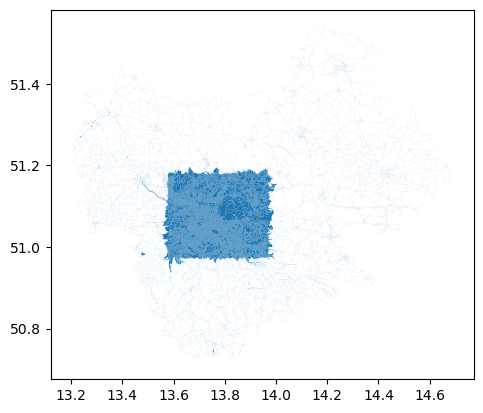

In [6]:
cropped_data.plot()

## Reclassify EUA

In [7]:
cropped_data['class_2018'].unique()

array(['Continuous urban fabric (S.L. : > 80%)',
       'Discontinuous dense urban fabric (S.L. : 50% -  80%)',
       'Green urban areas', 'Forests',
       'Industrial, commercial, public, military and private units',
       'Fast transit roads and associated land',
       'Railways and associated land', 'Land without current use',
       'Arable land (annual crops)', 'Isolated structures', 'Pastures',
       'Sports and leisure facilities', 'Airports',
       'Discontinuous medium density urban fabric (S.L. : 30% - 50%)',
       'Water',
       'Discontinuous low density urban fabric (S.L. : 10% - 30%)',
       'Discontinuous very low density urban fabric (S.L. : < 10%)',
       'Port areas', 'Mineral extraction and dump sites',
       'Permanent crops (vineyards, fruit trees, olive groves)',
       'Herbaceous vegetation associations (natural grassland, moors...)',
       'Other roads and associated land', 'Construction sites',
       'Wetlands'], dtype=object)

In [8]:
pugs_class_list = ['Green urban areas', 'Forests']

In [9]:
cropped_data['new_class'] = 0
cropped_data.loc[cropped_data['class_2018'].isin(pugs_class_list), 'new_class'] = 1

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
cropped_data.head()

,country,fua_name,fua_code,code_2018,class_2018,prod_date,identifier,perimeter,area,comment,Pop2018,geometry,new_class
0,DE,Dresden,DE009L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,828-DE009L2,409.909129,9933.170469,None,40,"MULTIPOLYGON (((13.86589 50.99284, 13.86521 50...",0
1,DE,Dresden,DE009L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,706-DE009L2,281.246324,4685.239982,None,54,"MULTIPOLYGON (((13.65059 50.9943, 13.65032 50....",0
2,DE,Dresden,DE009L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,1226-DE009L2,233.659641,3252.222933,None,22,"MULTIPOLYGON (((13.74793 51.01295, 13.74732 51...",0
3,DE,Dresden,DE009L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,1360-DE009L2,292.610137,5280.004514,None,63,"MULTIPOLYGON (((13.77715 51.03298, 13.77773 51...",0
4,DE,Dresden,DE009L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,2216-DE009L2,454.516410,12810.348334,None,237,"MULTIPOLYGON (((13.74704 51.07617, 13.7469 51....",0


In [11]:
cropped_data = cropped_data.to_crs(epsg=32633)

In [12]:
try:
   os.makedirs("../data/processed/ground truth")
except FileExistsError:
   # Directory already exists
   pass

# Save the cropped data
cropped_data[cropped_data['new_class'] == 1].to_file('../data/processed/ground truth/dresden_pugs_gt.geojson', driver='GeoJSON')